## Lab 8: Red Object Detection

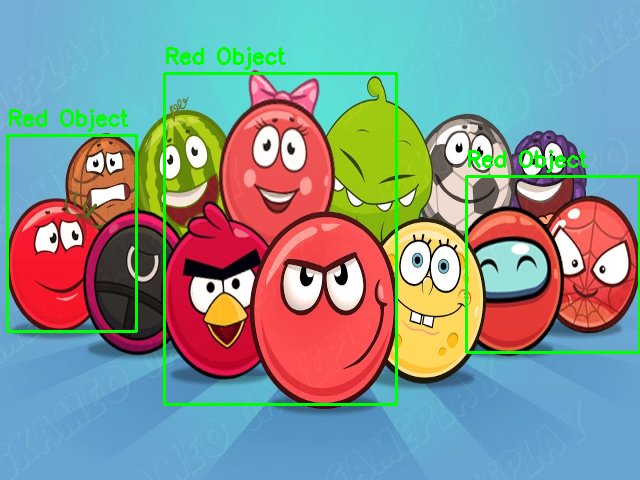

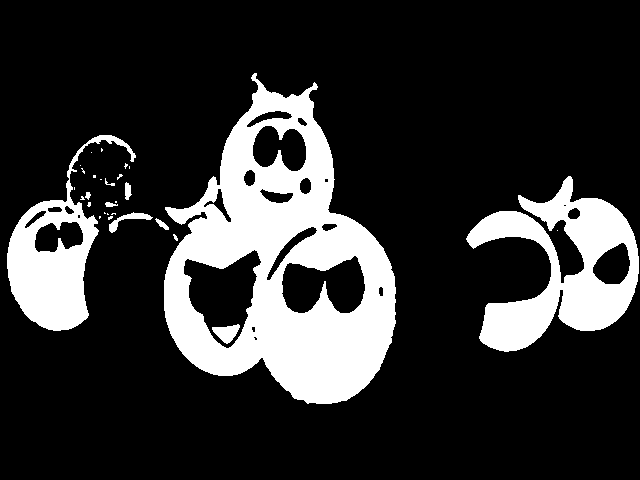

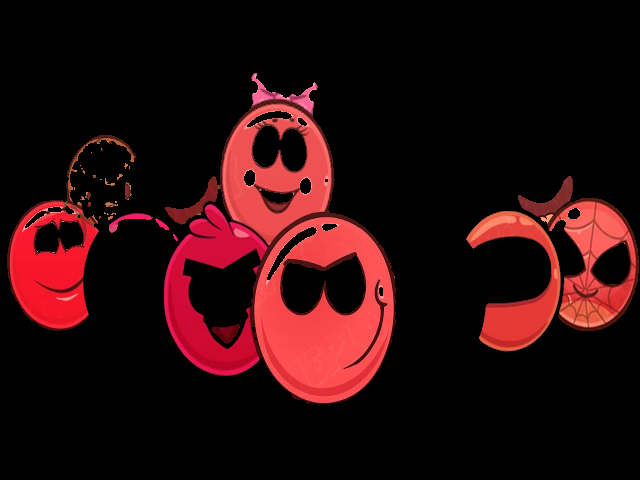

Press any key to close windows.


In [4]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Input file (use either image or video)
image_path = r"/content/exp_8.jpg"
video_path = None

# Define HSV range for Red color
lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

def process_frame(frame):
    frame = cv2.resize(frame, (640, 480))
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = mask1 | mask2
    mask = cv2.medianBlur(mask, 5)
    result = cv2.bitwise_and(frame, frame, mask=mask)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > 800:
            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(frame, "Red Object", (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    cv2_imshow(frame)
    cv2_imshow(mask)
    cv2_imshow(result)

# Image Input
if image_path and not video_path:
    frame = cv2.imread(image_path)
    if frame is not None:
        process_frame(frame)
        print("Press any key to close windows.")
        # cv2.waitKey(0) is not needed with cv2_imshow as it displays statically
        # cv2.destroyAllWindows() is also not needed

# # Video Input
# elif video_path:
#     cap = cv2.VideoCapture(video_path)
#     while True:
#         ret, frame = cap.read()
#         if not ret:
#             break
#         process_frame(frame)
#         if cv2.waitKey(1) & 0xFF == ord('q'):
#             break
#     cap.release()
#     # cv2.destroyAllWindows() is not needed